In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn

print(sys.executable)
print(pd.__version__)
print(np.__version__)
print(sklearn.__version__)

C:\Users\USER 1\Desktop\BaoBao\Education\Self Project\predictive-maintenance-pipeline\.venv\Scripts\python.exe
3.0.5
2.5.2
1.9.0


In [ ]:
#  inspection code
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "ai4i2020.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset path: c:\Users\USER 1\Desktop\BaoBao\Education\Self Project\predictive-maintenance-pipeline\data\ai4i2020.csv
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [ ]:
#  Inspect columns and data types
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Check missing values and duplicates
print("Missing values by column:")
display(df.isna().sum())

print(f"Duplicate rows: {df.duplicated().sum()}")

Missing values by column:


UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Duplicate rows: 0


In [4]:
# Inspect the target distribution
target_column = "Machine failure"

print("Target counts:")
display(df[target_column].value_counts().sort_index())

print("Target proportions:")
display(df[target_column].value_counts(normalize=True).sort_index())

Target counts:


Machine failure
0    9661
1     339
Name: count, dtype: int64

Target proportions:


Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

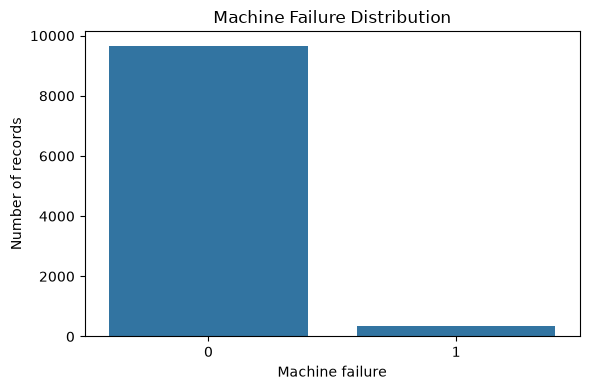

In [5]:
# Plot the target distribution
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=target_column)

plt.title("Machine Failure Distribution")
plt.xlabel("Machine failure")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

In [8]:
# Objective: Capture the exact dataset inspection results.
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
for column in df.columns:
    print(f"- {column}")

print("\nMissing values:")
display(df.isna().sum().to_frame("Missing_Count"))

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget counts:")
display(df[target_column].value_counts().sort_index().to_frame("Count"))

print("\nTarget proportions:")
display(
    (df[target_column].value_counts(normalize=True).sort_index() * 100)
    .round(2)
    .to_frame("Percentage")
)

Dataset shape:
(10000, 14)

Column names:
- UDI
- Product ID
- Type
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Tool wear [min]
- Machine failure
- TWF
- HDF
- PWF
- OSF
- RNF

Missing values:


,Missing_Count
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0



Duplicate rows:
0

Target counts:


,Count
Machine failure,
0,9661
1,339



Target proportions:


,Percentage
Machine failure,
0,96.61
1,3.39


In [ ]:
# Add the feature-selection cell
from sklearn.model_selection import train_test_split

target_column = "Machine failure"

feature_columns = [
    "Type",
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Selected features:")
print(list(X.columns))

print("\nTarget column:")
print(target_column)

print("\nFeature data types:")
display(X.dtypes)

Selected features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Target column:
Machine failure

Feature data types:


Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
dtype: object

In [10]:
# Verify excluded columns
excluded_columns = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

print("Excluded columns:")
print(excluded_columns)

print("\nExcluded columns still present in X:")
print([column for column in excluded_columns if column in X.columns])

Excluded columns:
['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Excluded columns still present in X:
[]


In [11]:
# Create the stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts().sort_index().to_frame("Count"))

print("\nTesting target distribution:")
display(y_test.value_counts().sort_index().to_frame("Count"))

Training feature shape: (8000, 6)
Testing feature shape: (2000, 6)

Training target distribution:


,Count
Machine failure,
0,7729
1,271



Testing target distribution:


,Count
Machine failure,
0,1932
1,68


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

categorical_features = ["Type"]

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("encoder", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            categorical_features,
        ),
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]
            ),
            numeric_features,
        ),
    ]
)

baseline_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DummyClassifier(strategy="most_frequent"),
        ),
    ]
)

baseline_pipeline.fit(X_train, y_train)

baseline_predictions = baseline_pipeline.predict(X_test)
baseline_probabilities = baseline_pipeline.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "accuracy": accuracy_score(y_test, baseline_predictions),
    "precision": precision_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        baseline_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(y_test, baseline_probabilities),
}

print("Baseline metrics:")
for metric, value in baseline_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nBaseline confusion matrix:")
print(confusion_matrix(y_test, baseline_predictions))

print("\nBaseline classification report:")
print(
    classification_report(
        y_test,
        baseline_predictions,
        zero_division=0,
    )
)

Baseline metrics:
accuracy: 0.9660
precision: 0.0000
recall: 0.0000
f1_score: 0.0000
roc_auc: 0.5000

Baseline confusion matrix:
[[1932    0]
 [  68    0]]

Baseline classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.00      0.00      0.00        68

    accuracy                           0.97      2000
   macro avg       0.48      0.50      0.49      2000
weighted avg       0.93      0.97      0.95      2000



In [13]:
# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Build a complete machine-learning pipeline
# The preprocessor handles Type and numeric sensor features.
# The classifier trains the Random Forest model.
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,        # Train 200 decision trees
                class_weight="balanced", # Give more importance to minority failures
                random_state=42,         # Ensure reproducible results
                n_jobs=-1,               # Use all available CPU cores
            ),
        ),
    ]
)

# Train the model only on the training data
random_forest_pipeline.fit(X_train, y_train)

# Predict the class label: 0 = no failure, 1 = failure
rf_predictions = random_forest_pipeline.predict(X_test)

# Predict the probability that each machine will fail
# [:, 1] selects the probability of class 1
rf_probabilities = random_forest_pipeline.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_metrics = {
    "accuracy": accuracy_score(
        y_test,
        rf_predictions,
    ),
    "precision": precision_score(
        y_test,
        rf_predictions,
        zero_division=0,
    ),
    "recall": recall_score(
        y_test,
        rf_predictions,
        zero_division=0,
    ),
    "f1_score": f1_score(
        y_test,
        rf_predictions,
        zero_division=0,
    ),
    "roc_auc": roc_auc_score(
        y_test,
        rf_probabilities,
    ),
}

# Display the Random Forest metric values
print("Random Forest metrics:")

for metric, value in rf_metrics.items():
    print(f"{metric}: {value:.4f}")

# Display the confusion matrix
# Rows represent actual classes.
# Columns represent predicted classes.
print("\nRandom Forest confusion matrix:")
print(confusion_matrix(y_test, rf_predictions))

# Display precision, recall, and F1 score for each class
print("\nRandom Forest classification report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0,
    )
)

Random Forest metrics:
accuracy: 0.9795
precision: 0.7143
recall: 0.6618
f1_score: 0.6870
roc_auc: 0.9721

Random Forest confusion matrix:
[[1914   18]
 [  23   45]]

Random Forest classification report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.71      0.66      0.69        68

    accuracy                           0.98      2000
   macro avg       0.85      0.83      0.84      2000
weighted avg       0.98      0.98      0.98      2000



In [14]:
# Combine both models' metrics into one table
comparison = pd.DataFrame(
    [baseline_metrics, rf_metrics],
    index=["DummyClassifier", "RandomForest"],
)

# Round values to four decimal places for easier reading
display(comparison.round(4))

,accuracy,precision,recall,f1_score,roc_auc
DummyClassifier,0.9660,0.0000,0.0000,0.000,0.5000
RandomForest,0.9795,0.7143,0.6618,0.687,0.9721


In [ ]:
#“The DummyClassifier achieved 96.60% accuracy but detected none of the failure cases, showing that accuracy alone was misleading because the target was imbalanced. 
# The class-weighted Random Forest achieved 66.18% recall, 71.43% precision, 68.70% F1 score, and 0.9721 ROC-AUC on the stratified test set. 
# Its confusion matrix showed 45 detected failures, 23 missed failures, and 18 false alarms.”
#Do not describe this as deployment or production performance. It is an offline evaluation on the AI4I dataset.

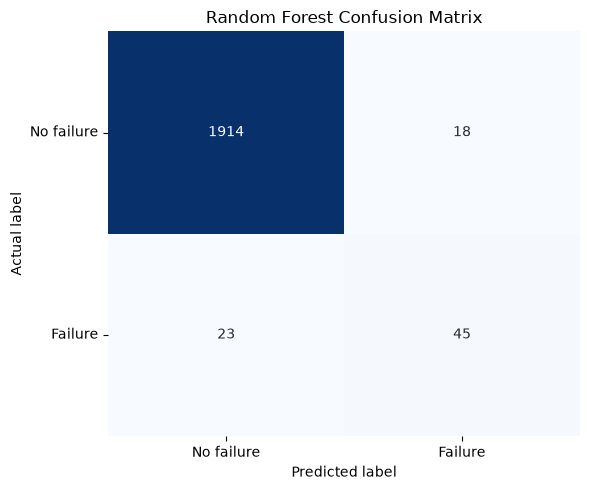

Saved chart to: c:\Users\USER 1\Desktop\BaoBao\Education\Self Project\predictive-maintenance-pipeline\outputs\figures\confusion_matrix.png


In [15]:
# Import the tools needed to create evaluation charts
from pathlib import Path

from sklearn.inspection import permutation_importance

# Create the output folders if they do not already exist
FIGURES_PATH = PROJECT_ROOT / "outputs" / "figures"
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Create a confusion matrix from the Random Forest predictions
rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_predictions,
)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_confusion_matrix,
    annot=True,       # Display the values inside each cell
    fmt="d",          # Format values as integers
    cmap="Blues",     # Use a blue colour scale
    cbar=False,
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("Actual label")
plt.xticks(
    ticks=[0.5, 1.5],
    labels=["No failure", "Failure"],
)
plt.yticks(
    ticks=[0.5, 1.5],
    labels=["No failure", "Failure"],
    rotation=0,
)
plt.tight_layout()

# Save the chart for GitHub and Power BI documentation
confusion_matrix_path = FIGURES_PATH / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {confusion_matrix_path}")

,Feature,Importance
0,Torque [Nm],0.413591
1,Rotational speed [rpm],0.404134
2,Air temperature [K],0.225043
3,Tool wear [min],0.138969
4,Process temperature [K],0.071890
5,Type,0.020821


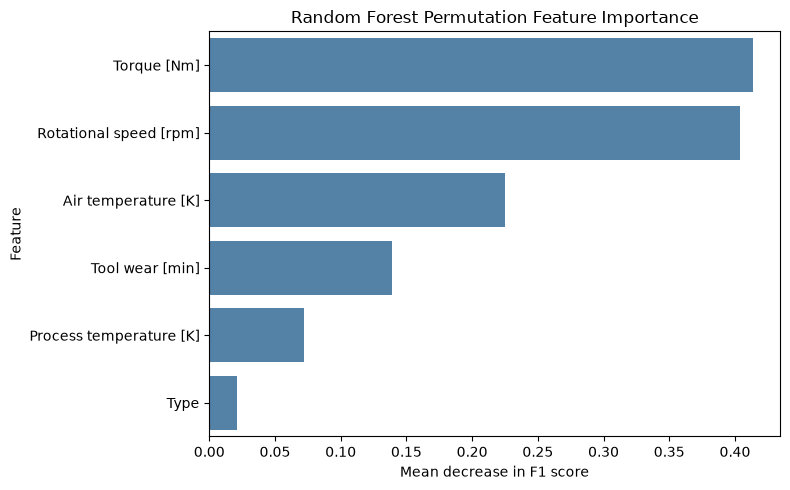

Saved chart to: c:\Users\USER 1\Desktop\BaoBao\Education\Self Project\predictive-maintenance-pipeline\outputs\figures\feature_importance.png


In [16]:
# Calculate permutation importance on the original test features
# This keeps the importance values connected to the six original input features.
permutation_result = permutation_importance(
    random_forest_pipeline,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
)

# Store feature importance results in a table
feature_importance = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Importance": permutation_result.importances_mean,
    }
)

# Sort the most important features to the top
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False,
).reset_index(drop=True)

# Display the feature importance table
display(feature_importance)

# Create a horizontal bar chart
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color="steelblue",
)

plt.title("Random Forest Permutation Feature Importance")
plt.xlabel("Mean decrease in F1 score")
plt.ylabel("Feature")
plt.tight_layout()

# Save the chart for the project outputs
feature_importance_path = FIGURES_PATH / "feature_importance.png"
plt.savefig(feature_importance_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to: {feature_importance_path}")

In [17]:
# Import tools for saving JSON and trained models
import json
import joblib

# Create the main output directory if it does not exist
OUTPUTS_PATH = PROJECT_ROOT / "outputs"
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

# Copy the test features so we can attach predictions to the original sensor values
predictions_for_powerbi = X_test.copy()

# Add the actual target values from the test set
predictions_for_powerbi["Actual_Machine_Failure"] = y_test.to_numpy()

# Add the model's predicted class labels
predictions_for_powerbi["Predicted_Machine_Failure"] = rf_predictions

# Add the probability of the failure class
predictions_for_powerbi["Failure_Risk_Probability"] = rf_probabilities

# Save the prediction data for Power BI
predictions_path = OUTPUTS_PATH / "predictions_for_powerbi.csv"
predictions_for_powerbi.to_csv(predictions_path, index=False)

# Save the feature-importance table
feature_importance_path = OUTPUTS_PATH / "feature_importance.csv"
feature_importance.to_csv(feature_importance_path, index=False)

# Prepare the metrics and project configuration for JSON export
metrics_output = {
    "accuracy": float(rf_metrics["accuracy"]),
    "precision": float(rf_metrics["precision"]),
    "recall": float(rf_metrics["recall"]),
    "f1_score": float(rf_metrics["f1_score"]),
    "roc_auc": float(rf_metrics["roc_auc"]),
    "model_name": "RandomForestClassifier",
    "split_configuration": {
        "test_size": 0.20,
        "random_state": 42,
        "stratify": True,
    },
    "class_imbalance_method": "class_weight=balanced",
    "test_records": int(len(y_test)),
    "test_failures": int(y_test.sum()),
}

# Save the metrics as a readable JSON file
metrics_path = OUTPUTS_PATH / "metrics.json"
with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(metrics_output, file, indent=4)

# Save the complete preprocessing-and-model pipeline
model_path = OUTPUTS_PATH / "model.joblib"
joblib.dump(random_forest_pipeline, model_path)

# Confirm the generated files
for output_path in [
    predictions_path,
    feature_importance_path,
    metrics_path,
    model_path,
]:
    print(f"{output_path.name}: {output_path.stat().st_size:,} bytes")

predictions_for_powerbi.csv: 74,585 bytes
feature_importance.csv: 247 bytes
metrics.json: 448 bytes
model.joblib: 7,513,275 bytes


In [19]:
# Make a copy so we do not accidentally modify the original object
predictions_for_powerbi = predictions_for_powerbi.copy()

# Add a unique row number for Power BI only
# This is not used as a machine-learning feature.
predictions_for_powerbi.insert(
    0,
    "Record_ID",
    range(1, len(predictions_for_powerbi) + 1),
)

# Save the updated CSV
predictions_for_powerbi.to_csv(
    predictions_path,
    index=False,
)

print("Record_ID added successfully.")
print(predictions_for_powerbi.columns.tolist())

Record_ID added successfully.
['Record_ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Actual_Machine_Failure', 'Predicted_Machine_Failure', 'Failure_Risk_Probability']


In [20]:
# Check whether the new column exists in the notebook data
print("Record_ID exists:", "Record_ID" in predictions_for_powerbi.columns)

# Show the first five record IDs
display(predictions_for_powerbi[["Record_ID"]].head())

# Confirm the CSV was saved with the new column
print("CSV path:", predictions_path)

Record_ID exists: True


,Record_ID
2997,1
4871,2
3858,3
951,4
6463,5


CSV path: c:\Users\USER 1\Desktop\BaoBao\Education\Self Project\predictive-maintenance-pipeline\outputs\predictions_for_powerbi.csv


In [21]:
# Read the saved CSV again to verify the file itself contains Record_ID
saved_predictions = pd.read_csv(predictions_path)

print(saved_predictions.columns.tolist())
print("Record_ID exists in CSV:", "Record_ID" in saved_predictions.columns)

['Record_ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Actual_Machine_Failure', 'Predicted_Machine_Failure', 'Failure_Risk_Probability']
Record_ID exists in CSV: True


In [18]:
# Display the exported prediction columns
print("Prediction columns:")
print(list(predictions_for_powerbi.columns))

# Display a sample of the exported records
display(predictions_for_powerbi.head())

# Display the saved metrics
print("Saved metrics:")
display(metrics_output)

Prediction columns:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Actual_Machine_Failure', 'Predicted_Machine_Failure', 'Failure_Risk_Probability']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Actual_Machine_Failure,Predicted_Machine_Failure,Failure_Risk_Probability
2997,L,300.5,309.8,1345,62.7,153,0,0,0.370
4871,L,303.7,312.4,1513,40.1,135,0,0,0.000
3858,L,302.5,311.4,1559,37.6,209,0,0,0.150
951,H,295.6,306.3,1509,35.8,60,0,0,0.005
6463,H,300.5,310.0,1358,60.4,102,0,0,0.135


Saved metrics:


{'accuracy': 0.9795,
 'precision': 0.7142857142857143,
 'recall': 0.6617647058823529,
 'f1_score': 0.6870229007633588,
 'roc_auc': 0.9720953598830837,
 'model_name': 'RandomForestClassifier',
 'split_configuration': {'test_size': 0.2,
  'random_state': 42,
  'stratify': True},
 'class_imbalance_method': 'class_weight=balanced',
 'test_records': 2000,
 'test_failures': 68}